### ***MEMBUAT PEMBELAJARAN DESAIN GROVER ALGORITHM***


### Penjelasan Library dan Fungsinya dalam Implementasi Algoritma Grover

---

### 1. Algoritma Utama

**Grover**

Mengimplementasikan algoritma Grover untuk pencarian kuantum.

Algoritma bekerja dengan melakukan iterasi operator:

$$
|\psi\rangle \rightarrow (D \cdot O)^k |\psi\rangle
$$

dengan:

- $O$ = Oracle (phase flip solusi)
- $D$ = Diffusion operator (inversion about the mean)
- $k \approx \sqrt{2^n}$

Untuk 11 qubit:

$$
k \approx 2^{11} = 2048
$$

---

**AmplificationProblem**

Mendefinisikan masalah pencarian yang akan diselesaikan oleh algoritma Grover.

Berisi:

- Oracle
- Kriteria solusi
- State awal (opsional)

Objek ini menjadi input utama bagi algoritma Grover.

---

### 2. Oracle

**PhaseOracleGate**

Membangun oracle berbasis ekspresi Boolean.

Oracle menerapkan transformasi:

$$
O|x\rangle =
\begin{cases}
-|x\rangle & \text{jika } x \text{ adalah solusi} \\
|x\rangle & \text{lainnya}
\end{cases}
$$

State solusi diberi fase negatif (phase flip), sedangkan state lain tidak berubah.

---

### 3. Simulator

**StatevectorSampler**

Simulator ideal berbasis statevector.

Untuk $n$ qubit:

$$
2^n \text{ amplitudo kompleks}
$$

Untuk 22 qubit:

$$
2^{22} = 4,194,304
$$

Digunakan untuk simulasi tanpa noise.

---

**AerSimulator**

Backend simulator klasik untuk menjalankan rangkaian kuantum.

Mode yang tersedia:

- Statevector
- Shot-based measurement
- Noise simulation

---

### 4. Konstruksi Rangkaian

**QuantumCircuit**

Digunakan untuk membangun rangkaian kuantum:

- Inisialisasi superposisi dengan Hadamard
- Penambahan oracle
- Penambahan diffusion operator
- Measurement

Superposisi awal:

$$
|\psi\rangle = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle
$$

---

**transpile**

Mengoptimasi rangkaian agar sesuai dengan backend.

Fungsi utama:

- Mengurangi depth circuit
- Mengubah gate agar kompatibel
- Mengoptimalkan performa eksekusi

---

### 5. Visualisasi dan Analisis

**plot_histogram**

Memvisualisasikan distribusi probabilitas hasil pengukuran.

Setelah amplifikasi amplitudo, probabilitas state solusi akan mendominasi histogram.

---

**numpy**

Digunakan untuk operasi numerik dan manipulasi array.

---

**matplotlib.pyplot**

Digunakan untuk plotting tambahan.

---

**display**

Menampilkan circuit dan hasil dalam format terstruktur di Jupyter Notebook.

---

### Alur Kerja Program

$$
\text{Oracle} \rightarrow \text{AmplificationProblem} \rightarrow \text{Grover} \rightarrow \text{Simulator} \rightarrow \text{Histogram}
$$

---

### Inti Implementasi

1. Membuat superposisi awal.
2. Menandai solusi menggunakan oracle.
3. Melakukan diffusion.
4. Mengulangi sekitar:

$$
k \approx \sqrt{2^n}
$$

5. Mengukur dan mengamati probabilitas maksimum pada state solusi.

# INPUT LIBRARY

In [12]:
#Import libraries
# importing qiskit
from qiskit_algorithms import Grover, AmplificationProblem
from qiskit.circuit.library import PhaseOracleGate
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
# import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# GROVER UNTUK KEADAAN MENGGUNAKAN MODUL ALGORITHMA QISKIT 


***Input Oracle***

In [ ]:
# ORACLE
oracle = PhaseOracleGate("a & b & c ")

problem = AmplificationProblem(oracle)

***Menginput jumlah iterasi dengan sampler jumlah $$\sqrt{2^n}$$ untuk n=jumlah qubit dan melakuakn pemroresan algorithma Grover***

In [ ]:
# SAMPLER

sampler = StatevectorSampler()

grover = Grover(sampler = sampler,iterations=2)

result = grover.amplify(problem)

print("Solution:", result.top_measurement)

***Visualisasi circuit disertai dengan hasil qubit yang dicari ditambah dengan probabilitas dari hasil qubit***

In [ ]:
# CIRCUIT VISUALIZATION

circuit = grover.construct_circuit(problem)

display(circuit.draw("mpl"))

# PROBABILITY DISTRIBUTION VISUALIZATION

# Ambil quasi distribution
quasi_dist = result.circuit_results[0]

# Ubah ke probabilitas normal (dictionary)
probabilities = dict(quasi_dist)

# Plot histogram
display(plot_histogram(probabilities))

# GROVER DENGAN TANPA ALGORITHMA BAWAAN LIBRARY

***Parameters***

In [58]:
# PARAMETERS
target = "101"  # Contoh target (harus sesuai dengan n)


In [59]:
n= len(target)  # Jumlah qubit berdasarkan panjang target
print("Jumlah qubit (n):", n)

Jumlah qubit (n): 3


***Oracle***

In [60]:
# ORACLE
def oracle_circuit(n, target):
    qc = QuantumCircuit(n)

    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    for i, bit in enumerate(target):
        if bit == "0":
            qc.x(i)

    return qc

***Operator Difusi***

In [61]:
# DIFFUSION OPERATOR
def diffusion_circuit(n):
    qc = QuantumCircuit(n)

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))

    return qc

***Sirkuit manual Grover***

In [62]:
# MAIN GROVER CIRCUIT
qc = QuantumCircuit(n, n)
qc.h(range(n))

oracle_gate = oracle_circuit(n, target).to_gate(label="Oracle")
diffusion_gate = diffusion_circuit(n).to_gate(label="Diffusion")

iterations = int(np.floor(np.pi/4 * np.sqrt(2**n)))

for _ in range(iterations):
    qc.append(oracle_gate, range(n))
    qc.append(diffusion_gate, range(n))

qc.measure(range(n), range(n))

***Visualisasi Gerbang dan simulasi pengukuran keadaan kuantum***

=== Circuit Grover ===


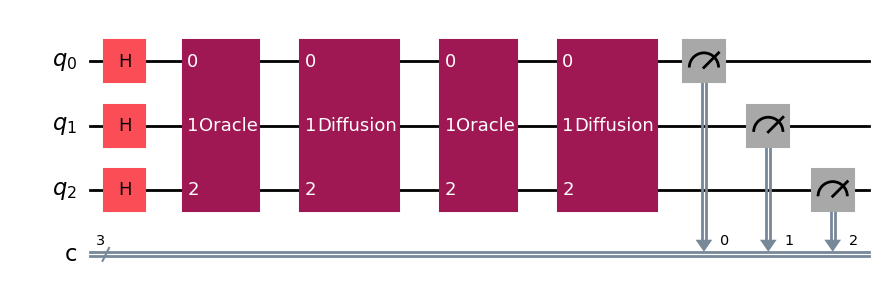

=== Oracle ===


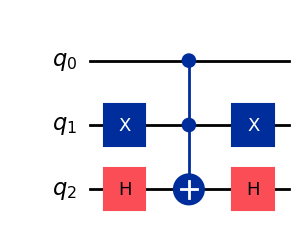

=== Diffusion Operator ===


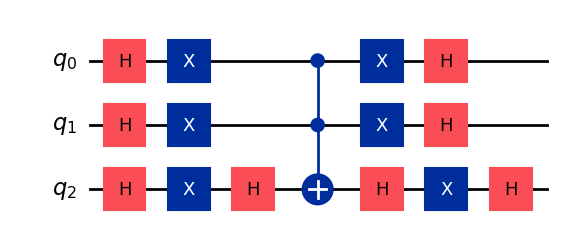

Target: 101
Measurement Result:
{'100': 9, '010': 6, '000': 10, '110': 12, '001': 10, '111': 7, '011': 9, '101': 961}
Probabilities: {'100': 0.0087890625, '010': 0.005859375, '000': 0.009765625, '110': 0.01171875, '001': 0.009765625, '111': 0.0068359375, '011': 0.0087890625, '101': 0.9384765625}


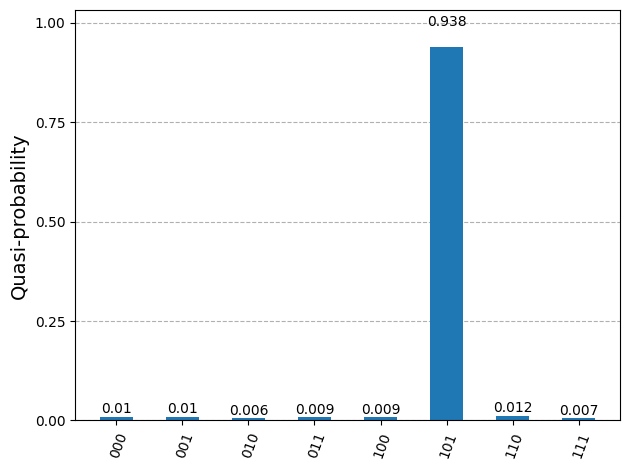

In [63]:
# VISUALISASI GERBANG
print("=== Circuit Grover ===")
display(qc.draw("mpl"))

print("=== Oracle ===")
display(oracle_circuit(n, target).draw("mpl"))

print("=== Diffusion Operator ===")
display(diffusion_circuit(n).draw("mpl"))

# SIMULASI

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print("Target:", target)
print("Measurement Result:")
print(counts)

total_shots = sum(counts.values())
probabilities = {k: v/total_shots for k, v in counts.items()}
print("Probabilities:", probabilities)
plot_histogram(probabilities)